# 02 — Feature Engineering & Scheme Detection

Computes roster features, merges game stats, derives style scores, and provides interactive sliders to tune scheme-detection thresholds.


In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.features import build_team_metrics, build_roster_features
from src.scheme_detector import compute_style_scores, apply_labels, build_scheme_widget

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

## Load raw data

In [2]:
stats_df     = pd.read_csv('../data/raw/team_stats/team_stats_raw.csv')
rosters_df   = pd.read_csv('../data/raw/rosters/rosters_raw.csv')
schedules_df = pd.read_csv('../data/raw/schedules/schedules_raw.csv')
print('Stats:', stats_df.shape, '| Rosters:', rosters_df.shape, '| Schedules:', schedules_df.shape)

Stats: (80, 52) | Rosters: (8494, 12) | Schedules: (1512, 10)


## Team-level metrics

`yards_per_play`, `pass_rate`, `havoc_rate` are NaN until Sports-Reference CSVs are imported (Step 4 of notebook 01). `points_per_game`, `win_pct`, `ivy_win_pct`, and `avg_margin` come from game data and are always populated.

In [3]:
metrics_df = build_team_metrics(stats_df)
print('Columns:', metrics_df.columns.tolist())
metrics_df[['school','year','points_per_game','points_allowed_per_game','win_pct','ivy_win_pct']].head(8)

Columns: ['school', 'year', 'games', 'wins', 'points_for', 'points_against', 'avg_margin', 'win_pct', 'point_diff', 'ivy_wins', 'ivy_games', 'ivy_avg_margin', 'ivy_win_pct', 'firstDowns', 'thirdDownEff', 'thirdDownEff_att', 'fourthDownEff', 'fourthDownEff_att', 'totalYards', 'netPassingYards', 'completionAttempts', 'completionAttempts_att', 'yardsPerPass', 'rushingYards', 'rushingAttempts', 'yardsPerRushAttempt', 'totalPenaltiesYards', 'totalPenaltiesYards_att', 'turnovers', 'fumblesLost', 'interceptions', 'totalFumbles', 'fumblesRecovered', 'kickingPoints', 'kickReturns', 'kickReturnTDs', 'kickReturnYards', 'passingTDs', 'puntReturns', 'puntReturnTDs', 'puntReturnYards', 'rushingTDs', 'passesIntercepted', 'interceptionTDs', 'interceptionYards', 'games_with_boxscore', 'passesDeflected', 'qbHurries', 'sacks', 'tackles', 'defensiveTDs', 'tacklesForLoss', 'points_per_game', 'points_allowed_per_game', 'pass_rate', 'rush_rate', 'yards_per_play', 'pace_proxy', 'turnovers_per_game', 'havoc_ra

,school,year,points_per_game,points_allowed_per_game,win_pct,ivy_win_pct
0,brown,2014,24.7,22.8,0.5,0.428571
1,brown,2015,27.9,32.9,0.5,0.428571
2,brown,2016,20.4,26.5,0.4,0.428571
3,brown,2017,13.0,30.1,0.2,0.000000
4,brown,2018,14.3,36.2,0.1,0.000000
5,brown,2019,30.0,40.2,0.2,0.142857
6,brown,2021,29.5,42.4,0.2,0.142857
7,brown,2022,23.1,35.1,0.3,0.142857


## Roster features

In [4]:
roster_feats = build_roster_features(rosters_df)
print('Roster feature columns:', roster_feats.columns.tolist())
print('Non-null OL_avg_weight:', roster_feats['OL_avg_weight'].notna().sum(), '/', len(roster_feats))
roster_feats.dropna(subset=['OL_avg_weight']).head(6)

Roster feature columns: ['school', 'year', 'OL_avg_weight', 'OL_n', 'OL_avg_height', 'SKILL_avg_weight', 'SKILL_n', 'SKILL_avg_height', 'DL_avg_weight', 'DL_n', 'DL_avg_height', 'LB_avg_weight', 'LB_n', 'LB_avg_height', 'DB_avg_weight', 'DB_n', 'DB_avg_height', 'DL_to_LB_weight_ratio', 'OL_vs_DL_weight_diff', 'roster_depth', 'upperclassman_ratio']
Non-null OL_avg_weight: 62 / 77


,school,year,OL_avg_weight,OL_n,OL_avg_height,SKILL_avg_weight,SKILL_n,SKILL_avg_height,DL_avg_weight,DL_n,...,LB_avg_weight,LB_n,LB_avg_height,DB_avg_weight,DB_n,DB_avg_height,DL_to_LB_weight_ratio,OL_vs_DL_weight_diff,roster_depth,upperclassman_ratio
0,brown,2014,275.476190,21,74.761905,212.096774,31,73.419355,245.625000,16,...,212.045455,22,72.545455,187.058824,17,70.882353,1.158360,29.851190,110,0.0
1,brown,2015,271.388889,18,75.055556,200.666667,30,72.833333,243.235294,17,...,207.500000,18,73.055556,184.000000,15,71.600000,1.172218,28.153595,102,0.0
2,brown,2016,273.947368,19,75.578947,201.285714,35,73.085714,240.937500,16,...,212.812500,16,73.250000,183.500000,20,71.750000,1.132159,33.009868,113,0.0
3,brown,2017,290.000000,19,75.631579,204.696970,33,73.030303,244.500000,20,...,210.294118,17,73.117647,185.869565,23,71.956522,1.162657,45.500000,117,0.0
4,brown,2018,288.750000,16,76.062500,201.111111,27,72.740741,262.333333,15,...,224.230769,13,73.384615,188.928571,14,71.714286,1.169926,26.416667,88,0.0
5,brown,2019,284.666667,15,75.933333,201.607143,28,73.142857,253.823529,17,...,220.833333,12,72.833333,189.285714,14,72.428571,1.149390,30.843137,89,0.0


## Merge into master dataset

`stats_df` already contains `ivy_win_pct` from game data, so we use it directly rather than recomputing.

In [5]:
master = metrics_df.merge(roster_feats, on=['school','year'], how='left')
print('Master shape:', master.shape)
print('Columns:', master.columns.tolist())
master[['school','year','ivy_win_pct','win_pct','points_per_game','OL_avg_weight','SKILL_avg_weight']].head(8)

Master shape: (80, 79)
Columns: ['school', 'year', 'games', 'wins', 'points_for', 'points_against', 'avg_margin', 'win_pct', 'point_diff', 'ivy_wins', 'ivy_games', 'ivy_avg_margin', 'ivy_win_pct', 'firstDowns', 'thirdDownEff', 'thirdDownEff_att', 'fourthDownEff', 'fourthDownEff_att', 'totalYards', 'netPassingYards', 'completionAttempts', 'completionAttempts_att', 'yardsPerPass', 'rushingYards', 'rushingAttempts', 'yardsPerRushAttempt', 'totalPenaltiesYards', 'totalPenaltiesYards_att', 'turnovers', 'fumblesLost', 'interceptions', 'totalFumbles', 'fumblesRecovered', 'kickingPoints', 'kickReturns', 'kickReturnTDs', 'kickReturnYards', 'passingTDs', 'puntReturns', 'puntReturnTDs', 'puntReturnYards', 'rushingTDs', 'passesIntercepted', 'interceptionTDs', 'interceptionYards', 'games_with_boxscore', 'passesDeflected', 'qbHurries', 'sacks', 'tackles', 'defensiveTDs', 'tacklesForLoss', 'points_per_game', 'points_allowed_per_game', 'pass_rate', 'rush_rate', 'yards_per_play', 'pace_proxy', 'turnove

,school,year,ivy_win_pct,win_pct,points_per_game,OL_avg_weight,SKILL_avg_weight
0,brown,2014,0.428571,0.5,24.7,275.476190,212.096774
1,brown,2015,0.428571,0.5,27.9,271.388889,200.666667
2,brown,2016,0.428571,0.4,20.4,273.947368,201.285714
3,brown,2017,0.000000,0.2,13.0,290.000000,204.696970
4,brown,2018,0.000000,0.1,14.3,288.750000,201.111111
5,brown,2019,0.142857,0.2,30.0,284.666667,201.607143
6,brown,2021,0.142857,0.2,29.5,278.611111,203.289474
7,brown,2022,0.142857,0.3,23.1,286.388889,205.000000


## Style scores — continuous [0,1] dimensions

In [6]:
style_df = compute_style_scores(master)
print('Style columns:', [c for c in style_df.columns if c not in ['school','year']])
style_df.head(8)

Style columns: ['pass_tendency', 'tempo', 'spread_factor', 'explosiveness', 'aggression', 'front_heaviness', 'coverage_depth']


,school,year,pass_tendency,tempo,spread_factor,explosiveness,aggression,front_heaviness,coverage_depth
0,brown,2014,NaN,NaN,0.122698,NaN,NaN,0.270339,NaN
1,brown,2015,NaN,NaN,0.948897,NaN,NaN,0.395769,NaN
2,brown,2016,NaN,NaN,0.901747,NaN,NaN,0.033190,NaN
3,brown,2017,NaN,NaN,0.647045,NaN,NaN,0.309233,NaN
4,brown,2018,NaN,NaN,0.915016,NaN,NaN,0.375018,NaN
5,brown,2019,NaN,NaN,0.877380,NaN,NaN,0.189147,NaN
6,brown,2021,NaN,NaN,0.751100,NaN,NaN,0.201743,NaN
7,brown,2022,0.70893,1.0,0.624829,0.14527,NaN,0.362229,NaN


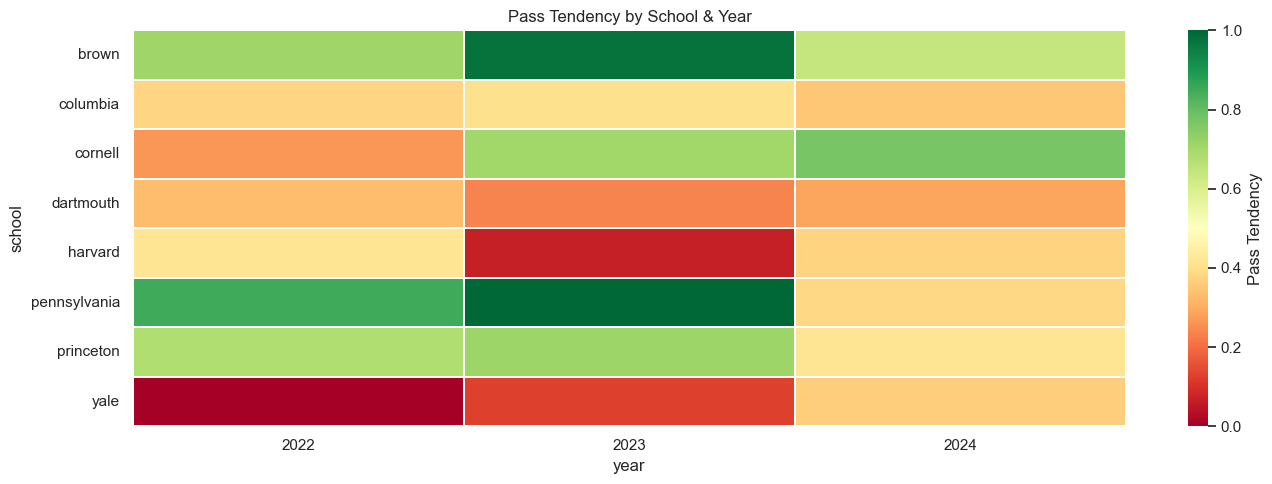

In [7]:
style_cols = ['pass_tendency','tempo','spread_factor','explosiveness','aggression','front_heaviness']
available  = [c for c in style_cols if c in style_df.columns and style_df[c].notna().sum() > 0]

if available:
    pivot = style_df.dropna(subset=available, how='all').pivot_table(
        index='school', columns='year', values=available[0]
    )
    fig, ax = plt.subplots(figsize=(14,5))
    sns.heatmap(pivot, cmap='RdYlGn', center=0.5, ax=ax, linewidths=0.3,
                cbar_kws={'label': available[0].replace('_',' ').title()})
    ax.set_title(f'{available[0].replace("_"," ").title()} by School & Year')
    plt.tight_layout()
    plt.savefig('../data/processed/style_heatmap.png', dpi=150)
    plt.show()
else:
    print('Style scores need S-R stat columns (pass_rate, yards_per_play). Import CSVs via notebook 01 Step 4.')

## Interactive Scheme Detection Sliders

In [8]:
build_scheme_widget(style_df)

C:\Users\B.Helfand26\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\io\formats\style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
C:\Users\B.Helfand26\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\io\formats\style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,school,year,off_scheme,def_scheme,pass_tendency,tempo,spread_factor,explosiveness,aggression
0,brown,2014,Pro-Style / Power Run,3-4 / 3-3-5,nan,nan,0.122698,nan,nan
1,brown,2015,Spread Run,3-4 / 3-3-5,nan,nan,0.948897,nan,nan
2,brown,2016,Spread Run,3-4 / 3-3-5,nan,nan,0.901747,nan,nan
3,brown,2017,Spread Run,3-4 / 3-3-5,nan,nan,0.647045,nan,nan
4,brown,2018,Spread Run,3-4 / 3-3-5,nan,nan,0.915016,nan,nan
5,brown,2019,Spread Run,3-4 / 3-3-5,nan,nan,0.877380,nan,nan
6,brown,2021,Spread Run,3-4 / 3-3-5,nan,nan,0.751100,nan,nan
7,brown,2022,Air Raid / Spread RPO,3-4 / 3-3-5,0.708930,1.000000,0.624829,0.145270,nan
8,brown,2023,Air Raid / Spread RPO,3-4 / 3-3-5,0.972740,0.898477,0.828877,0.488945,nan
9,brown,2024,Air Raid / Spread RPO,3-4 / 3-3-5,0.640032,0.786802,0.066844,0.409214,nan


## Export master dataset

In [9]:
labeled = apply_labels(style_df)
# Include style scores in the exported file so notebook 03 can use them
master_labeled = master.merge(
    labeled[['school','year','off_scheme','def_scheme',
             'pass_tendency','tempo','spread_factor',
             'explosiveness','aggression','front_heaviness']],
    on=['school','year'], how='left'
)
master_labeled.to_csv('../data/processed/master_labeled.csv', index=False)
print('Saved master_labeled.csv —', master_labeled.shape)
master_labeled[['school','year','off_scheme','def_scheme','ivy_win_pct','win_pct','points_per_game']].head(12)

Saved master_labeled.csv — (80, 87)


,school,year,off_scheme,def_scheme,ivy_win_pct,win_pct,points_per_game
0,brown,2014,Pro-Style / Power Run,3-4 / 3-3-5,0.428571,0.5,24.7
1,brown,2015,Spread Run,3-4 / 3-3-5,0.428571,0.5,27.9
2,brown,2016,Spread Run,3-4 / 3-3-5,0.428571,0.4,20.4
3,brown,2017,Spread Run,3-4 / 3-3-5,0.000000,0.2,13.0
4,brown,2018,Spread Run,3-4 / 3-3-5,0.000000,0.1,14.3
5,brown,2019,Spread Run,3-4 / 3-3-5,0.142857,0.2,30.0
6,brown,2021,Spread Run,3-4 / 3-3-5,0.142857,0.2,29.5
7,brown,2022,Air Raid / Spread RPO,3-4 / 3-3-5,0.142857,0.3,23.1
8,brown,2023,Air Raid / Spread RPO,3-4 / 3-3-5,0.428571,0.5,25.5
9,brown,2024,Air Raid / Spread RPO,3-4 / 3-3-5,0.285714,0.3,25.5
